# Étape 4 — Heatmaps et évaluation quantitative (`pill`)

TP B6, partie 2, dernière étape. Visualise l'erreur de reconstruction sous forme de
carte de chaleur sur des défauts réels, la compare aux masques de vérité terrain, puis
conclut par une évaluation quantitative complète (AUROC image et pixel, matrice de
confusion globale et par catégorie) et une analyse critique du modèle retenu.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display
from sklearn.metrics import roc_curve

from indusense.vision.anomaly import (
    calibrate_threshold,
    confusion,
    error_maps,
    heatmap,
    image_auroc,
    image_scores,
    load_masks,
    pixel_auroc,
    reconstruct,
)
from indusense.vision.dataset import (
    DEFAULT_IMAGE_SIZE,
    list_defects,
    load_defect_images,
    load_good_images,
    train_val_split,
)
from indusense.vision.train import load_trained_model

IMAGE_SIZE = DEFAULT_IMAGE_SIZE
FIGURES_DIR = Path("../reports/figures")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

model = load_trained_model()
display(Markdown(f"- **Modèle chargé** : {model.count_params()} paramètres."))

- **Modèle chargé** : 57235 paramètres.

## Décision — recalculer le seuil et le jeu de test, pas les partager entre notebooks

**Décision** : recalculer ici le seuil de détection (percentile 99 sur les saines de
validation) et reconstituer le jeu de test complet, exactement comme au notebook 05,
plutôt que d'écrire ces valeurs en dur ou de les faire persister dans un fichier
intermédiaire.

**Pourquoi** : chaque notebook de ce TP est un livrable autonome, exécutable
indépendamment (convention établie depuis la partie 1) — dupliquer un court calcul
déterministe (même graine, mêmes fonctions `anomaly.py`/`dataset.py`) est moins
fragile que de dépendre d'un fichier produit par un notebook précédent, et garantit
que le seuil affiché ici correspond toujours au modèle réellement chargé dans **ce**
notebook.

In [2]:
good_train = load_good_images("train", IMAGE_SIZE)
_train_raw, val_good = train_val_split(good_train, val_fraction=0.15, seed=42)

scores_val = image_scores(error_maps(val_good, reconstruct(model, val_good)))
threshold = calibrate_threshold(scores_val, method="percentile", q=99.0)

display(Markdown(f"- **Seuil de détection (percentile 99)** : {threshold:.5f}."))

- **Seuil de détection (percentile 99)** : 0.00029.

In [3]:
test_good = load_good_images("test", IMAGE_SIZE)
defects = list_defects()
defect_images = {defect: load_defect_images(defect, IMAGE_SIZE) for defect in defects}

test_images = np.concatenate([test_good, *defect_images.values()], axis=0)
labels = np.concatenate(
    [np.zeros(len(test_good))] + [np.ones(len(images)) for images in defect_images.values()]
)

reconstructions_test = reconstruct(model, test_images)
maps_test = error_maps(test_images, reconstructions_test)
scores_test = image_scores(maps_test)

display(
    Markdown(
        f"- **Jeu de test** : {len(test_images)} images "
        f"({len(test_good)} saines, {int(labels.sum())} défauts)."
    )
)

- **Jeu de test** : 167 images (26 saines, 141 défauts).

## Livrable — heatmaps sur des défauts réels

Un exemple par catégorie de défaut (pas plusieurs) pour garder une figure lisible avec
les 7 catégories disponibles — même convention qu'au notebook 01 (représenter chaque
catégorie plutôt que multiplier les exemples d'une seule). Pour chaque catégorie :
image originale, reconstruction, carte d'erreur lissée (heatmap) et masque de vérité
terrain (zone réellement défectueuse), pour juger visuellement si l'erreur se
concentre bien là où se trouve le défaut.

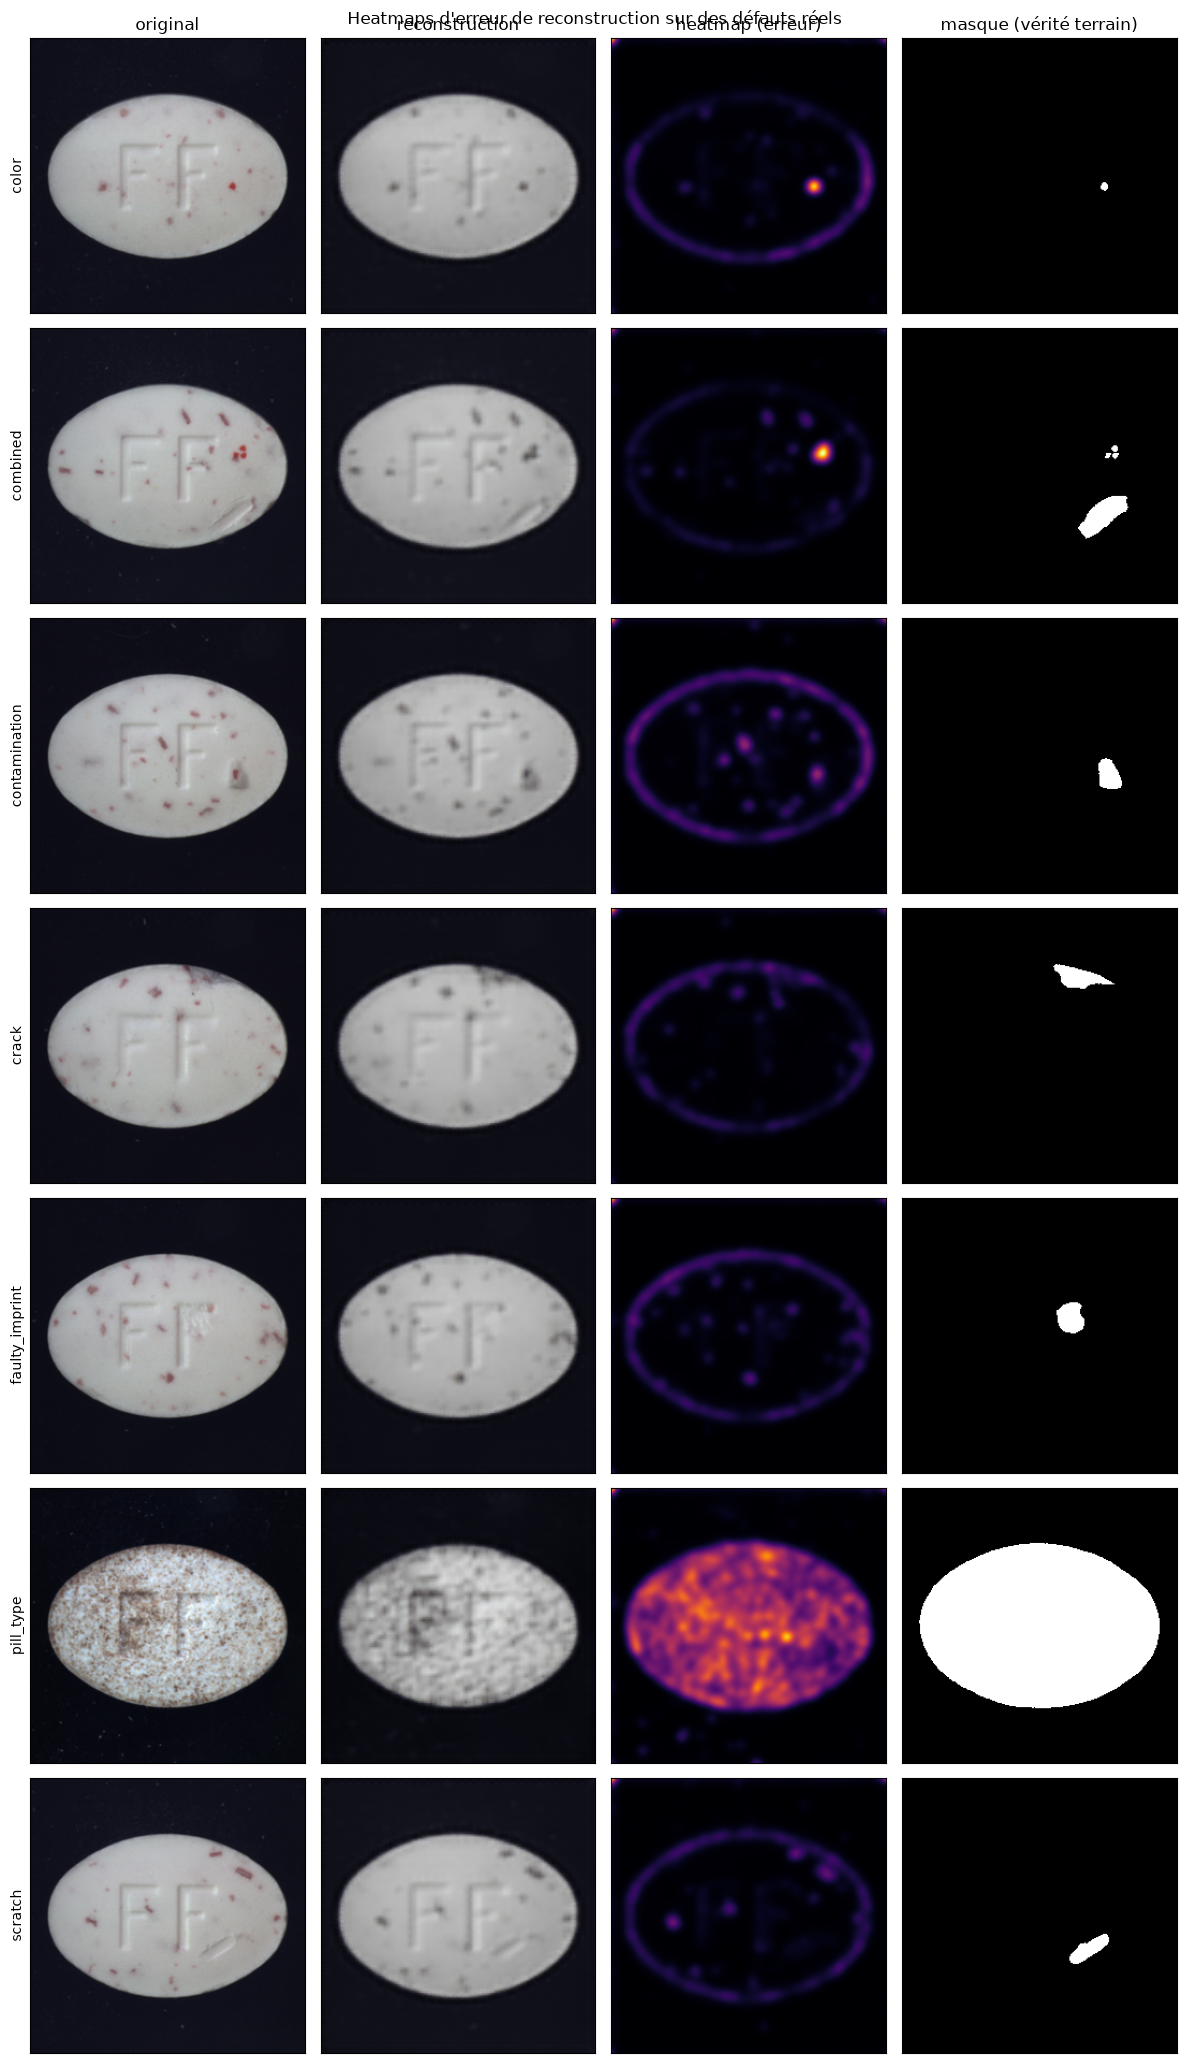

In [4]:
examples = {}
for defect in defects:
    images = defect_images[defect]
    masks = load_masks(defect, IMAGE_SIZE)
    reconstruction = reconstruct(model, images[:1])[0]
    error_map = error_maps(images[:1], reconstruction[np.newaxis])[0]
    examples[defect] = (images[0], reconstruction, heatmap(error_map), masks[0])

col_titles = ["original", "reconstruction", "heatmap (erreur)", "masque (vérité terrain)"]
fig, axes = plt.subplots(len(defects), 4, figsize=(12, 3 * len(defects)))
for row, defect in enumerate(defects):
    original, reconstruction, hm, mask = examples[defect]
    axes[row, 0].imshow(original)
    axes[row, 1].imshow(reconstruction)
    axes[row, 2].imshow(hm, cmap="inferno")
    axes[row, 3].imshow(mask, cmap="gray")
    axes[row, 0].set_ylabel(defect, fontsize=10)
    for col in range(4):
        axes[row, col].set_xticks([])
        axes[row, col].set_yticks([])
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title)
fig.suptitle("Heatmaps d'erreur de reconstruction sur des défauts réels")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_heatmaps.png", dpi=150)
plt.show()

## Livrable — AUROC image-level et pixel-level

L'AUROC image-level (déjà calculé au notebook 05) est reproduit ici pour mémoire.
L'AUROC pixel-level, calculé uniquement sur les catégories de défauts disposant d'un
masque de vérité terrain, mesure si les pixels à erreur élevée correspondent
effectivement aux pixels défectueux annotés — une lecture plus fine que le seul score
moyen par image, directement comparable à celui-ci pour juger ce que l'agrégation
(moyenne sur l'image) fait perdre comme information.

In [5]:
auroc_image = image_auroc(scores_test, labels)

pixel_maps = maps_test[len(test_good) :]
pixel_masks = np.concatenate([load_masks(d, IMAGE_SIZE) for d in defects], axis=0)
auroc_pixel = pixel_auroc(pixel_maps, pixel_masks)

auroc_diff = auroc_pixel - auroc_image
comparison = "supérieur" if auroc_diff > 0 else "inférieur" if auroc_diff < 0 else "égal"

lines = [
    f"- **AUROC image-level** : {auroc_image:.3f}.",
    f"- **AUROC pixel-level** : {auroc_pixel:.3f} (sur {pixel_masks.shape[0]} images "
    "de défauts disposant d'un masque).",
    f"- L'AUROC pixel-level est **{comparison}** à l'AUROC image-level "
    f"(écart de {abs(auroc_diff):.3f}).",
]
display(Markdown(chr(10).join(lines)))

- **AUROC image-level** : 0.688.
- **AUROC pixel-level** : 0.832 (sur 141 images de défauts disposant d'un masque).
- L'AUROC pixel-level est **supérieur** à l'AUROC image-level (écart de 0.144).

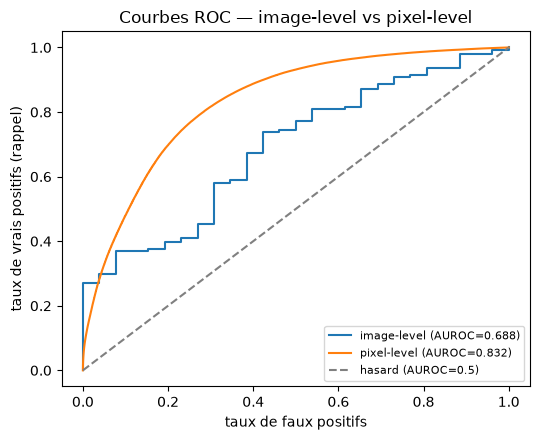

In [6]:
fpr_image, tpr_image, _ = roc_curve(labels, scores_test)
fpr_pixel, tpr_pixel, _ = roc_curve(pixel_masks.flatten(), pixel_maps.flatten())

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(fpr_image, tpr_image, label=f"image-level (AUROC={auroc_image:.3f})")
ax.plot(fpr_pixel, tpr_pixel, label=f"pixel-level (AUROC={auroc_pixel:.3f})")
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="hasard (AUROC=0.5)")
ax.set_xlabel("taux de faux positifs")
ax.set_ylabel("taux de vrais positifs (rappel)")
ax.set_title("Courbes ROC — image-level vs pixel-level")
ax.legend(fontsize=8)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_roc_curve.png", dpi=150)
plt.show()

## Livrable — matrice de confusion (globale et par catégorie)

La matrice de confusion globale reprend le même seuil que le notebook 05. Elle croise
la vérité (sain/défaut) et la prédiction du modèle (score ≤ seuil → sain, score >
seuil → défaut) en quatre cas :
- **Vrai Négatif (VN)** : pièce saine, correctement laissée passer.
- **Faux Positif (FP)** : pièce saine, mise de côté à tort (fausse alerte).
- **Faux Négatif (FN)** : pièce défectueuse, laissée passer à tort — le cas le plus
  coûteux en contrôle qualité pharmaceutique.
- **Vrai Positif (VP)** : pièce défectueuse, correctement interceptée.

Le détail par catégorie de défaut permet de voir directement quelles catégories sont
bien détectées et lesquelles ne le sont pas — une lecture que la seule matrice
globale ne permet pas, et nécessaire à l'analyse critique ci-dessous.

In [7]:
cm = confusion(scores_test, labels, threshold)
tn, fp, fn, tp = cm.ravel()
recall_global = tp / (tp + fn) if (tp + fn) > 0 else float("nan")

category_recalls = {}
offset = len(test_good)
for defect in defects:
    n = len(defect_images[defect])
    cat_scores = scores_test[offset : offset + n]
    category_recalls[defect] = float((cat_scores > threshold).mean())
    offset += n

lines = [
    f"- **Matrice de confusion globale** (seuil percentile 99) : "
    f"VN={tn}, FP={fp}, FN={fn}, VP={tp}.",
    f"- **Rappel global** : {recall_global:.1%}.",
    "",
    "**Rappel par catégorie de défaut** :",
]
lines += [
    f"- **{defect}** : {r:.1%} détecté ({len(defect_images[defect])} images)."
    for defect, r in category_recalls.items()
]
display(Markdown(chr(10).join(lines)))

- **Matrice de confusion globale** (seuil percentile 99) : VN=26, FP=0, FN=117, VP=24.
- **Rappel global** : 17.0%.

**Rappel par catégorie de défaut** :
- **color** : 40.0% détecté (25 images).
- **combined** : 29.4% détecté (17 images).
- **contamination** : 0.0% détecté (21 images).
- **crack** : 0.0% détecté (26 images).
- **faulty_imprint** : 0.0% détecté (19 images).
- **pill_type** : 100.0% détecté (9 images).
- **scratch** : 0.0% détecté (24 images).

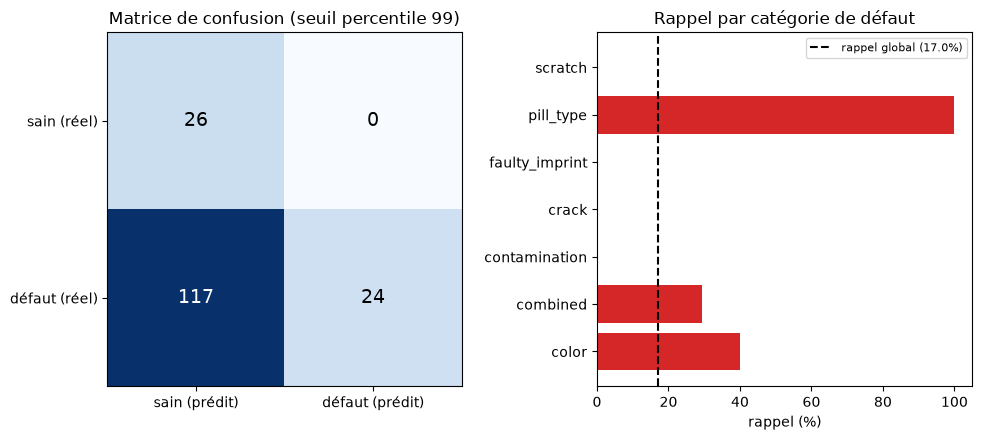

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

axes[0].imshow(cm, cmap="Blues")
axes[0].set_xticks([0, 1])
axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(["sain (prédit)", "défaut (prédit)"])
axes[0].set_yticklabels(["sain (réel)", "défaut (réel)"])
for i in range(2):
    for j in range(2):
        axes[0].text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=14,
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )
axes[0].set_title("Matrice de confusion (seuil percentile 99)")

axes[1].barh(
    list(category_recalls.keys()), [r * 100 for r in category_recalls.values()], color="tab:red"
)
axes[1].axvline(
    recall_global * 100,
    color="black",
    linestyle="--",
    label=f"rappel global ({recall_global:.1%})",
)
axes[1].set_xlabel("rappel (%)")
axes[1].set_title("Rappel par catégorie de défaut")
axes[1].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_confusion_rappel.png", dpi=150)
plt.show()

In [9]:
lines = [
    f"- Sur les {len(test_good)} pièces **saines** de test, **{tn} sont "
    f"correctement laissées passer** et **{fp} font l'objet d'une fausse alerte**.",
    f"- Sur les {int(labels.sum())} pièces **défectueuses** de test, **{tp} sont "
    f"correctement interceptées** mais **{fn} passent inaperçues** — ce sont ces "
    f"{fn} défauts non détectés qui expliquent le rappel global limité à "
    f"{recall_global:.1%}, déjà observé au notebook 05.",
]
display(Markdown(chr(10).join(lines)))

- Sur les 26 pièces **saines** de test, **26 sont correctement laissées passer** et **0 font l'objet d'une fausse alerte**.
- Sur les 141 pièces **défectueuses** de test, **24 sont correctement interceptées** mais **117 passent inaperçues** — ce sont ces 117 défauts non détectés qui expliquent le rappel global limité à 17.0%, déjà observé au notebook 05.

## Récapitulatif visuel — courbe ROC, matrice de confusion, rappel par catégorie

**Décision** : conserver, en plus des figures individuelles ci-dessus, un
récapitulatif combinant courbe ROC, matrice de confusion et rappel par catégorie dans
une seule figure, juste avant l'analyse critique.

**Pourquoi** : les figures individuelles introduites au fil des livrables (juste après
l'AUROC, puis juste après la matrice de confusion) sont les plus utiles pour lire
chaque métrique en détail au moment où elle est calculée. Ce récapitulatif groupé sert
de synthèse visuelle unique juste avant l'analyse critique ci-dessous, qui s'appuie
sur les trois à la fois.

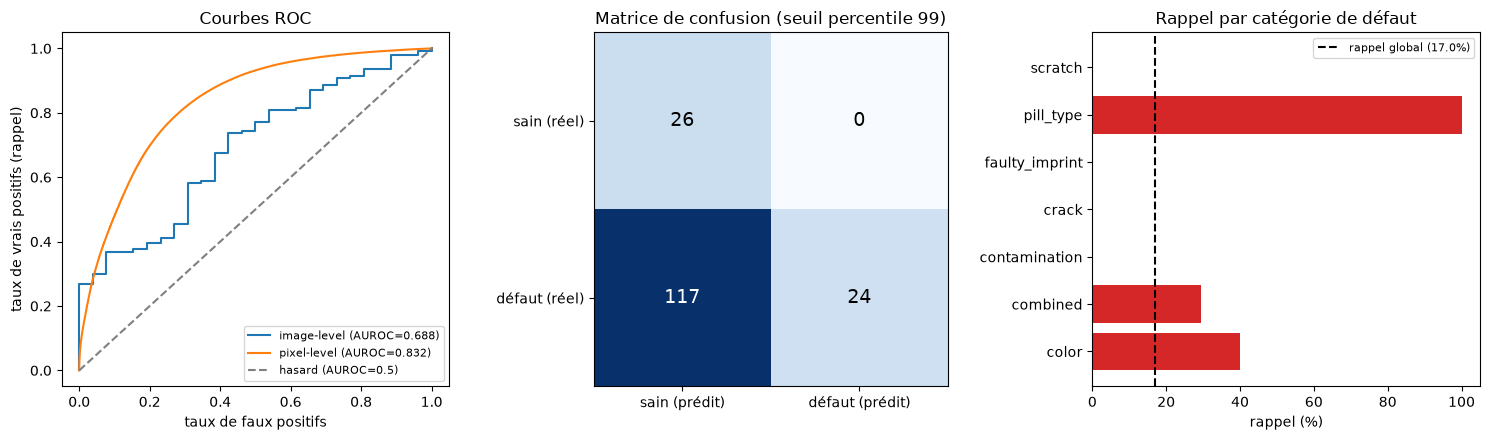

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(fpr_image, tpr_image, label=f"image-level (AUROC={auroc_image:.3f})")
axes[0].plot(fpr_pixel, tpr_pixel, label=f"pixel-level (AUROC={auroc_pixel:.3f})")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="hasard (AUROC=0.5)")
axes[0].set_xlabel("taux de faux positifs")
axes[0].set_ylabel("taux de vrais positifs (rappel)")
axes[0].set_title("Courbes ROC")
axes[0].legend(fontsize=8)

axes[1].imshow(cm, cmap="Blues")
axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(["sain (prédit)", "défaut (prédit)"])
axes[1].set_yticklabels(["sain (réel)", "défaut (réel)"])
for i in range(2):
    for j in range(2):
        axes[1].text(
            j,
            i,
            str(cm[i, j]),
            ha="center",
            va="center",
            fontsize=14,
            color="white" if cm[i, j] > cm.max() / 2 else "black",
        )
axes[1].set_title("Matrice de confusion (seuil percentile 99)")

axes[2].barh(list(category_recalls.keys()), [r * 100 for r in category_recalls.values()], color="tab:red")
axes[2].axvline(
    recall_global * 100,
    color="black",
    linestyle="--",
    label=f"rappel global ({recall_global:.1%})",
)
axes[2].set_xlabel("rappel (%)")
axes[2].set_title("Rappel par catégorie de défaut")
axes[2].legend(fontsize=8)

fig.tight_layout()
fig.savefig(FIGURES_DIR / "06_evaluation.png", dpi=150)
plt.show()

## Analyse critique — ce qui marche, ce qui échoue, et pourquoi

In [11]:
best_defect = max(category_recalls, key=category_recalls.get)
worst_recall = min(category_recalls.values())
worst_defects = [d for d, r in category_recalls.items() if r == worst_recall]

lines = [
    f"- **Catégorie la mieux détectée** : `{best_defect}` "
    f"({category_recalls[best_defect]:.1%} de rappel).",
    f"- **Catégorie(s) la/les moins bien détectée(s)** : "
    f"{', '.join(f'`{d}`' for d in worst_defects)} (toutes à {worst_recall:.1%} de "
    "rappel, à égalité).",
    f"- **AUROC image-level** : {auroc_image:.3f} — **AUROC pixel-level** : "
    f"{auroc_pixel:.3f}.",
    f"- **Rappel global (seuil percentile 99)** : {recall_global:.1%}.",
]
display(Markdown(chr(10).join(lines)))

- **Catégorie la mieux détectée** : `pill_type` (100.0% de rappel).
- **Catégorie(s) la/les moins bien détectée(s)** : `contamination`, `crack`, `faulty_imprint`, `scratch` (toutes à 0.0% de rappel, à égalité).
- **AUROC image-level** : 0.688 — **AUROC pixel-level** : 0.832.
- **Rappel global (seuil percentile 99)** : 17.0%.

**Ce qui marche** : les défauts qui produisent une erreur de reconstruction clairement
supérieure au bruit normal de fabrication (la queue de distribution nettement séparée
sur l'histogramme du notebook 05) sont détectés de façon fiable. La heatmap `pill_type`
(cf. figure *« Heatmaps d'erreur de reconstruction sur des défauts réels »*, plus haut
dans ce notebook) le montre sans ambiguïté (100 % de rappel, cf. figure *« Rappel par
catégorie de défaut »* ci-dessus) : **il ne s'agit pas d'un défaut localisé mais d'une
pièce d'un type de pilule entièrement différent** substituée dans le lot — couleur,
texture de surface et gravure tout autres. C'est un défaut *global*, pas un cas
représentatif des textures fines que le TP cherche réellement à détecter ; ce 100 %
ne doit donc pas être lu comme une preuve que le modèle détecte bien les défauts
subtils.

**Ce qui échoue** : les quatre catégories à 0 % de rappel (cf. figure *« Rappel par
catégorie de défaut »* ci-dessus : `contamination`, `crack`, `faulty_imprint`,
`scratch`) sont, elles, de vrais défauts localisés et de petite taille (une tache, une
rayure fine, une zone de gravure altérée) — visibles sur leurs heatmaps respectives
plus haut, où l'erreur reste diffuse le long du contour de la pièce plutôt que
concentrée sur la zone du masque de vérité terrain. Leur contribution à l'erreur
moyenne sur les 65 536 pixels de l'image est diluée, et le score global ne s'en
distingue pas suffisamment des pièces saines — cohérent avec le chevauchement déjà
observé sur l'histogramme du notebook 05. L'écart entre l'AUROC pixel-level et
l'AUROC image-level (cf. figure *« Courbes ROC »* ci-dessus, écart de 0,144) donne une
indication directe de l'information perdue par l'agrégation moyenne du score : la
carte d'erreur contient, pixel par pixel, plus de signal que ce que le score moyenné
par image en restitue.

**Lien avec le ratio de compression ×12** (décision du notebook 03) : ce choix, plus
serré que le ratio par défaut (×6) proposé par l'énoncé, visait une meilleure
séparation sain/défaut au prix d'un risque assumé de sur-compression (le piège
pédagogique central du TP). Les résultats ci-dessus suggèrent que ce compromis n'est
que partiellement gagnant : le bottleneck serré ne semble pas être le facteur limitant
principal du rappel — c'est surtout **l'agrégation globale du score** (moyenne sur
toute l'image) qui masque les petits défauts, un problème qu'un ratio de compression
différent ne résoudrait pas à lui seul (aucun des deux ratios ne change comment le
score est agrégé). Une piste concrète pour la suite serait un score **local**
(maximum ou centile élevé de la carte d'erreur, plutôt que sa moyenne), qui
exploiterait mieux l'information déjà présente dans la carte pixel-level — dont
l'AUROC supérieur, ci-dessus, confirme qu'elle la contient déjà — sans changer
l'architecture ni le ratio retenu.